# Trabalho 4

## Parte 1

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.color import label2rgb


In [89]:
def carregar_imagem_colorida(caminho):
    imagem_colorida = cv2.imread(caminho)
    imagem_colorida = cv2.cvtColor(imagem_colorida, cv2.COLOR_BGR2RGB)
    return imagem_colorida

def converter_para_cinza(imagem_colorida):
    return cv2.cvtColor(imagem_colorida, cv2.COLOR_RGB2GRAY)

def segmentar_objetos(imagem_cinza):
    _, binaria = cv2.threshold(imagem_cinza, 250, 255, cv2.THRESH_BINARY_INV)
    return binaria

def encontrar_contornos(imagem_binaria):
    contornos, _ = cv2.findContours(imagem_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contornos

def extrair_propriedades(imagem_binaria, imagem_colorida):
    rotulos = label(imagem_binaria)
    props = regionprops(rotulos)

    print(f"Número de regiões: {len(props)}")
    for i, regiao in enumerate(props):
        print(f"Região {i}: área = {regiao.area}, perímetro = {regiao.perimeter:.2f}, "
              f"excentricidade = {regiao.eccentricity:.3f}, solidez = {regiao.solidity:.3f}")

    imagem_rotulada = label2rgb(rotulos, image=imagem_colorida, bg_label=0)

    # Plotar imagem rotulada com apenas os números (sem box)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(imagem_rotulada)
    ax.set_title("Imagem Rotulada com Índices")
    ax.axis('off')

    for i, regiao in enumerate(props):
        y, x = regiao.centroid
        ax.text(x, y, str(i), color='black', fontsize=8, ha='center', va='center', weight='bold')

    plt.show()

    return imagem_rotulada, props

def obter_imagem_somente_contornos(imagem_binaria):
    contornos = encontrar_contornos(imagem_binaria)

    # Cria imagem preta
    somente_contornos = np.zeros_like(imagem_binaria)
    # Desenha os contornos em branco
    cv2.drawContours(somente_contornos, contornos, -1, 255, 1)  # 1 pixel de espessura

    return somente_contornos


def classificar_e_histograma(props):
    areas = [r.area for r in props]
    pequenas = sum(a < 1500 for a in areas)
    medias = sum(1500 <= a < 3000 for a in areas)
    grandes = sum(a >= 3000 for a in areas)

    print(f"Pequenas: {pequenas}, Médias: {medias}, Grandes: {grandes}")

    plt.hist(areas, bins=3, color='gray', edgecolor='black')
    plt.title('Histograma das Áreas')
    plt.xlabel('Área')
    plt.ylabel('Frequência')
    plt.show()


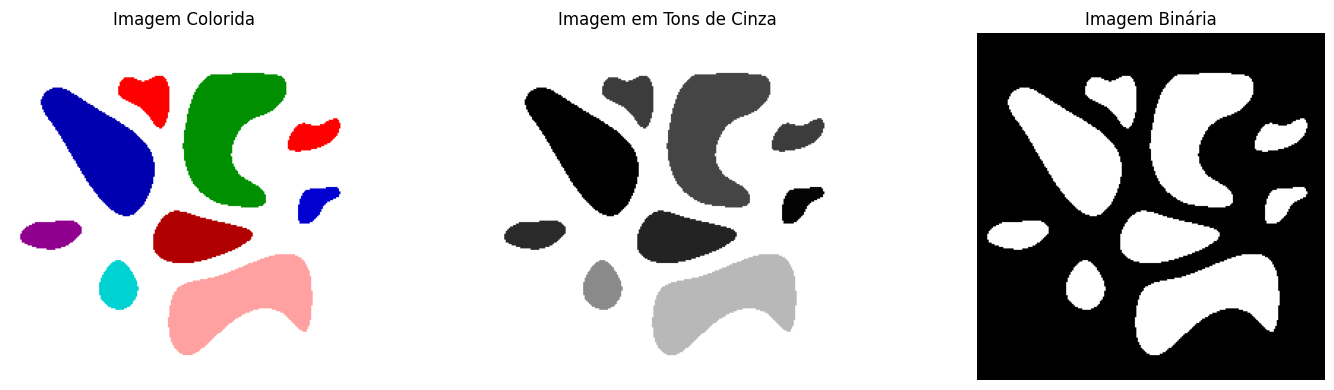

In [90]:
# Substitua pelo caminho da sua imagem local
caminho_imagem = 'objetos3.png'  # ou arraste o arquivo no Jupyter

imagem_colorida = carregar_imagem_colorida(caminho_imagem)
imagem_cinza = converter_para_cinza(imagem_colorida)
imagem_binaria = segmentar_objetos(imagem_cinza)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(imagem_colorida)
plt.title("Imagem Colorida")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagem_cinza, cmap='gray')
plt.title("Imagem em Tons de Cinza")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagem_binaria, cmap='gray')
plt.title("Imagem Binária")
plt.axis('off')

plt.tight_layout()
plt.show()


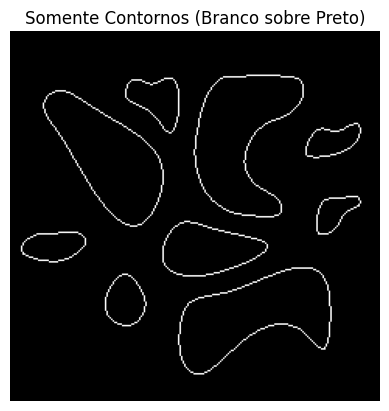

In [91]:
contornos_apenas = obter_imagem_somente_contornos(imagem_binaria)

plt.imshow(contornos_apenas, cmap='gray')
plt.title("Somente Contornos (Branco sobre Preto)")
plt.axis('off')
plt.show()


Número de regiões: 9
Região 0: área = 3969.0, perímetro = 313.76, excentricidade = 0.816, solidez = 0.747
Região 1: área = 791.0, perímetro = 119.98, excentricidade = 0.741, solidez = 0.896
Região 2: área = 3584.0, perímetro = 259.46, excentricidade = 0.898, solidez = 0.976
Região 3: área = 540.0, perímetro = 99.25, excentricidade = 0.890, solidez = 0.902
Região 4: área = 438.0, perímetro = 88.77, excentricidade = 0.856, solidez = 0.909
Região 5: área = 1684.0, perímetro = 174.12, excentricidade = 0.868, solidez = 0.967
Região 6: área = 642.0, perímetro = 103.01, excentricidade = 0.890, solidez = 0.963
Região 7: área = 3934.0, perímetro = 305.42, excentricidade = 0.911, solidez = 0.773
Região 8: área = 675.0, perímetro = 96.33, excentricidade = 0.620, solidez = 0.970


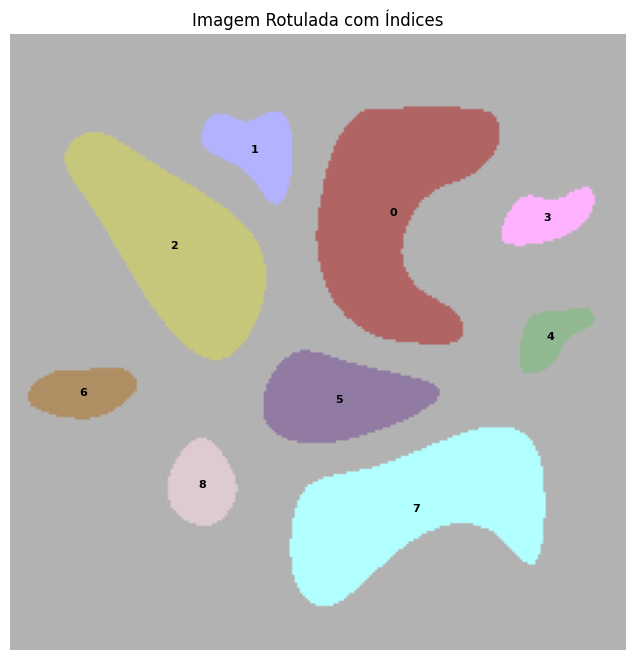

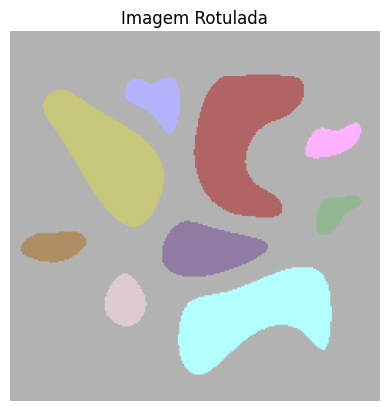

Pequenas: 5, Médias: 1, Grandes: 3


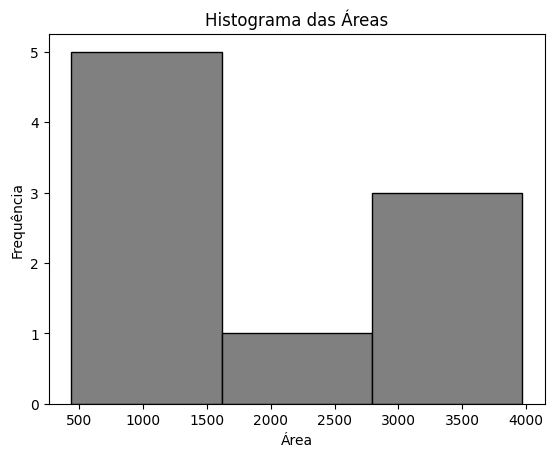

In [92]:
imagem_rotulada, props = extrair_propriedades(imagem_binaria, imagem_colorida)

plt.imshow(imagem_rotulada)
plt.title("Imagem Rotulada")
plt.axis('off')
plt.show()

classificar_e_histograma(props)


# Parte 2

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


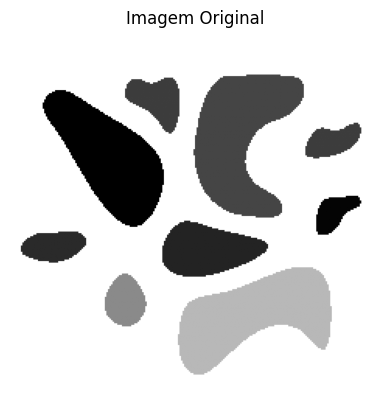

In [67]:
# Substitua pelo caminho correto ou use upload no Jupyter
imagem_path = 'objetos3.png'

# Carrega como array float [0, 255]
imagem = np.array(Image.open(imagem_path).convert('L')).astype(np.float32)

plt.imshow(imagem, cmap='gray')
plt.title("Imagem Original")
plt.axis('off')
plt.show()


In [68]:

def interpolacao_vizinho_mais_proximo(imagem, x, y):
    h, w = imagem.shape
    x_round = int(round(x))
    y_round = int(round(y))
    if 0 <= x_round < w and 0 <= y_round < h:
        return imagem[y_round, x_round]
    else:
        return 0  # pixel fora da imagem

In [69]:
def escalar(imagem, fator_escala, interpolador):
    h, w = imagem.shape
    novo_h = int(h * fator_escala)
    novo_w = int(w * fator_escala)
    
    # Manter o mesmo tipo da imagem original para evitar problemas na visualização
    imagem_escalada = np.zeros((novo_h, novo_w), dtype=imagem.dtype)
    
    for y in range(novo_h):
        for x in range(novo_w):
            orig_x = x / fator_escala
            orig_y = y / fator_escala
            imagem_escalada[y, x] = interpolador(imagem, orig_x, orig_y)
    
    return imagem_escalada


In [70]:
def rotacionar(imagem, angulo_graus, interpolador):
    ang = np.deg2rad(angulo_graus)
    h, w = imagem.shape

    cos = np.cos(ang)
    sin = np.sin(ang)

    # Dimensões da imagem de saída (retângulo que envolve a rotação)
    new_w = int(abs(w * cos) + abs(h * sin))
    new_h = int(abs(h * cos) + abs(w * sin))

    cx, cy = w / 2, h / 2
    new_cx, new_cy = new_w / 2, new_h / 2

    imagem_rotacionada = np.zeros((new_h, new_w), dtype=np.float32)

    for y in range(new_h):
        for x in range(new_w):
            # coordenadas na imagem original
            dx = x - new_cx
            dy = y - new_cy
            orig_x = cos * dx + sin * dy + cx
            orig_y = -sin * dx + cos * dy + cy
            imagem_rotacionada[y, x] = interpolador(imagem, orig_x, orig_y)
    
    return imagem_rotacionada


In [93]:
imagem_esc = escalar(imagem, fator_escala=1.05, interpolador=interpolacao_vizinho_mais_proximo)
imagem_rot = rotacionar(imagem, angulo_graus=30, interpolador=interpolacao_vizinho_mais_proximo)

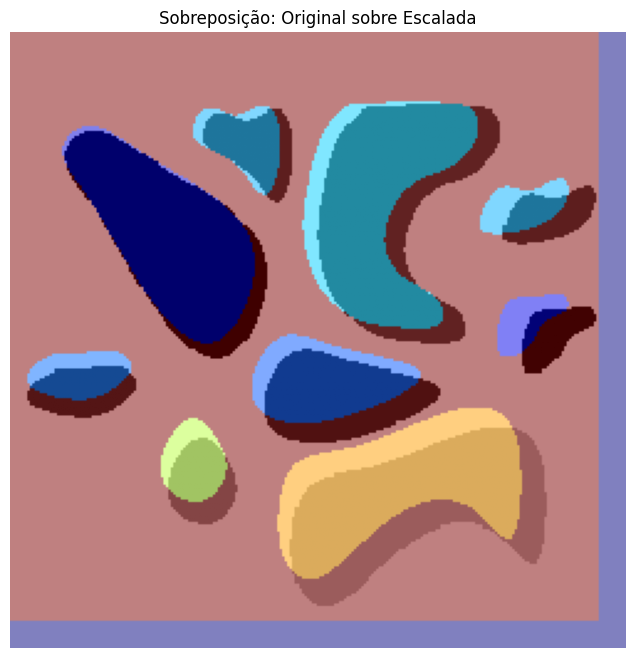

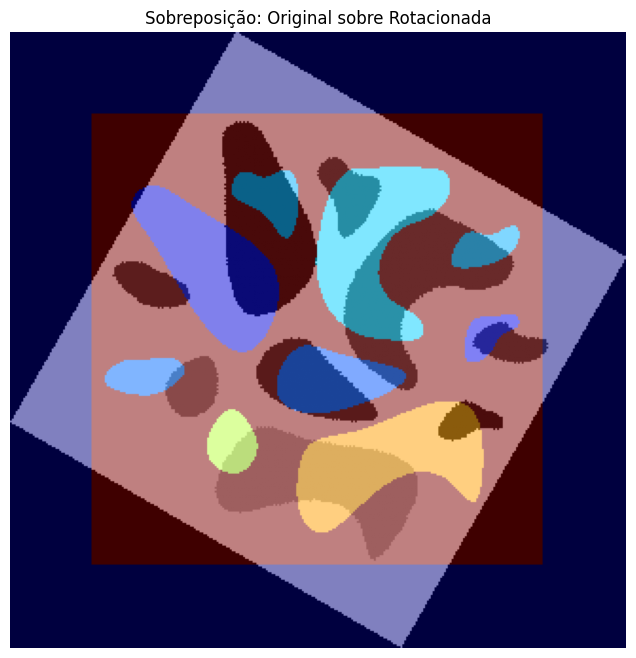

In [94]:
# Sobreposição: Original sobre Escalada
h_esc, w_esc = imagem_esc.shape
h_ori, w_ori = imagem.shape

canvas_esc = np.zeros_like(imagem_esc)
canvas_esc[:h_ori, :w_ori] = imagem

plt.figure(figsize=(8, 8))
plt.imshow(imagem_esc, cmap='gray', alpha=1.0)  # fundo: imagem escalada
plt.imshow(canvas_esc, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Escalada")
plt.axis('off')
plt.show()

# Sobreposição: Original sobre Rotacionada
h_rot, w_rot = imagem_rot.shape

canvas_rot = np.zeros_like(imagem_rot)

offset_y = (h_rot - h_ori) // 2
offset_x = (w_rot - w_ori) // 2

if offset_y >= 0 and offset_x >= 0:
    canvas_rot[offset_y:offset_y+h_ori, offset_x:offset_x+w_ori] = imagem
else:
    canvas_rot[:min(h_rot, h_ori), :min(w_rot, w_ori)] = imagem[:min(h_rot, h_ori), :min(w_rot, w_ori)]

plt.figure(figsize=(8, 8))
plt.imshow(imagem_rot, cmap='gray', alpha=1.0)  # fundo: imagem rotacionada
plt.imshow(canvas_rot, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Rotacionada")
plt.axis('off')
plt.show()


## Bilinear

In [73]:
def interpolacao_bilinear(imagem, x, y):
    h, w = imagem.shape

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    dx = x - x0
    dy = y - y0

    # Coordenadas dos 4 vizinhos
    x1 = x0 + 1
    y1 = y0 + 1

    # Verifica se todos os vizinhos estão dentro da imagem
    if x0 < 0 or x1 >= w or y0 < 0 or y1 >= h:
        return 0.0

    # Intensidades dos 4 vizinhos
    f00 = imagem[y0, x0]
    f10 = imagem[y0, x1]
    f01 = imagem[y1, x0]
    f11 = imagem[y1, x1]

    # Aplicando a fórmula
    fxy = (1 - dx)*(1 - dy)*f00 + dx*(1 - dy)*f10 + (1 - dx)*dy*f01 + dx*dy*f11

    return fxy


In [76]:
imagem_esc = escalar(imagem, fator_escala=1.05, interpolador=interpolacao_bilinear)
imagem_rot = rotacionar(imagem, angulo_graus=30, interpolador=interpolacao_bilinear)


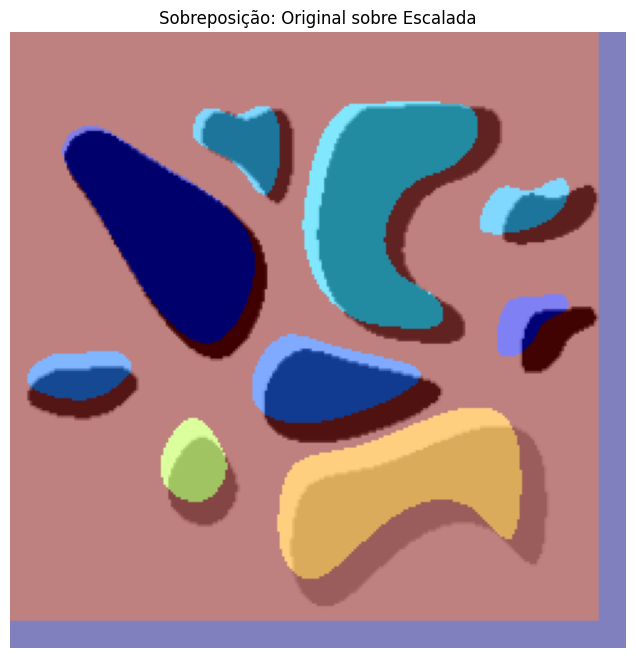

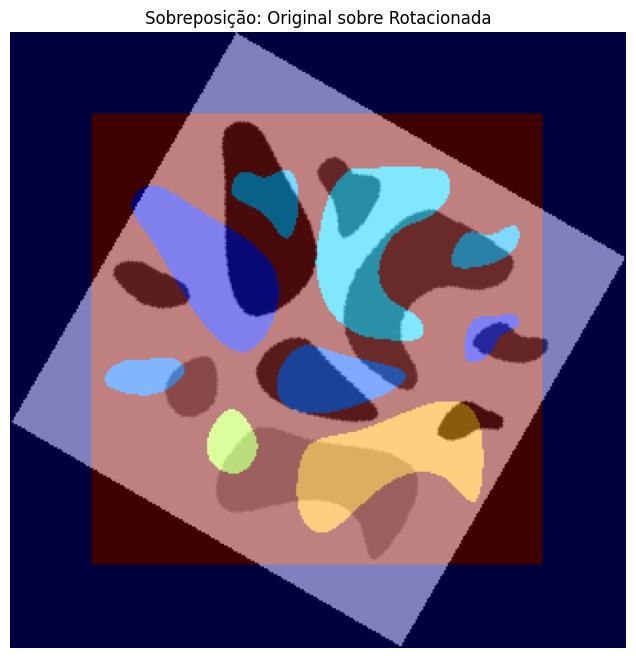

In [21]:
# Sobreposição: Original sobre Escalada
h_esc, w_esc = imagem_esc.shape
h_ori, w_ori = imagem.shape

canvas_esc = np.zeros_like(imagem_esc)
canvas_esc[:h_ori, :w_ori] = imagem

plt.figure(figsize=(8, 8))
plt.imshow(imagem_esc, cmap='gray', alpha=1.0)  # fundo: imagem escalada
plt.imshow(canvas_esc, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Escalada")
plt.axis('off')
plt.show()

# Sobreposição: Original sobre Rotacionada
h_rot, w_rot = imagem_rot.shape

canvas_rot = np.zeros_like(imagem_rot)

offset_y = (h_rot - h_ori) // 2
offset_x = (w_rot - w_ori) // 2

if offset_y >= 0 and offset_x >= 0:
    canvas_rot[offset_y:offset_y+h_ori, offset_x:offset_x+w_ori] = imagem
else:
    canvas_rot[:min(h_rot, h_ori), :min(w_rot, w_ori)] = imagem[:min(h_rot, h_ori), :min(w_rot, w_ori)]

plt.figure(figsize=(8, 8))
plt.imshow(imagem_rot, cmap='gray', alpha=1.0)  # fundo: imagem rotacionada
plt.imshow(canvas_rot, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Rotacionada")
plt.axis('off')
plt.show()


## Bicubica 

In [22]:
def P(t):
    return t if t > 0 else 0

def R(s):
    return (1/6) * (
        P(s + 2)**3 - 4 * P(s + 1)**3 + 6 * P(s)**3 - 4 * P(s - 1)**3
    )

def interpolacao_bicubica(imagem, x, y):
    h, w = imagem.shape
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    dx = x - x0
    dy = y - y0

    valor = 0.0
    for m in range(-1, 3):  # m = -1 a 2
        for n in range(-1, 3):
            xm = x0 + m
            yn = y0 + n

            if 0 <= xm < w and 0 <= yn < h:
                pixel = imagem[yn, xm]
                valor += pixel * R(m - dx) * R(dy - n)

    return np.clip(valor, 0, 255)


In [77]:
imagem_esc = escalar(imagem, fator_escala=1.05, interpolador=interpolacao_bicubica)
imagem_rot = rotacionar(imagem, angulo_graus=30, interpolador=interpolacao_bicubica)


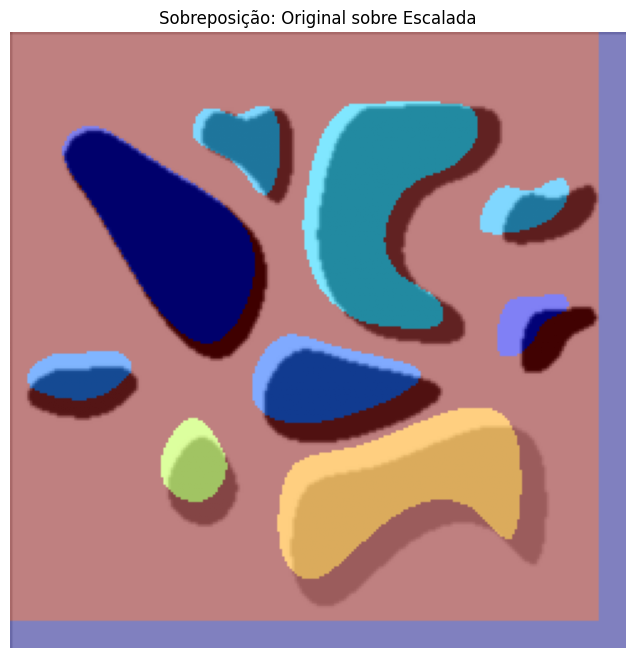

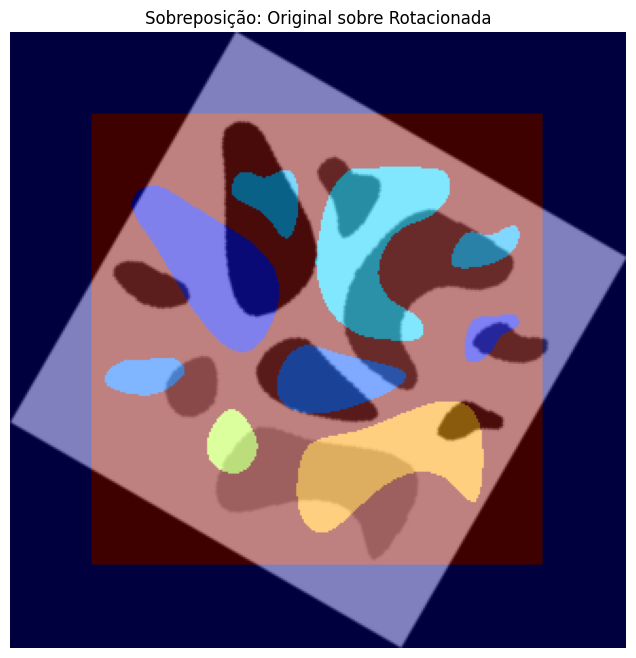

In [78]:
# Sobreposição: Original sobre Escalada
h_esc, w_esc = imagem_esc.shape
h_ori, w_ori = imagem.shape

canvas_esc = np.zeros_like(imagem_esc)
canvas_esc[:h_ori, :w_ori] = imagem

plt.figure(figsize=(8, 8))
plt.imshow(imagem_esc, cmap='gray', alpha=1.0)  # fundo: imagem escalada
plt.imshow(canvas_esc, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Escalada")
plt.axis('off')
plt.show()

# Sobreposição: Original sobre Rotacionada
h_rot, w_rot = imagem_rot.shape

canvas_rot = np.zeros_like(imagem_rot)

offset_y = (h_rot - h_ori) // 2
offset_x = (w_rot - w_ori) // 2

if offset_y >= 0 and offset_x >= 0:
    canvas_rot[offset_y:offset_y+h_ori, offset_x:offset_x+w_ori] = imagem
else:
    canvas_rot[:min(h_rot, h_ori), :min(w_rot, w_ori)] = imagem[:min(h_rot, h_ori), :min(w_rot, w_ori)]

plt.figure(figsize=(8, 8))
plt.imshow(imagem_rot, cmap='gray', alpha=1.0)  # fundo: imagem rotacionada
plt.imshow(canvas_rot, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Rotacionada")
plt.axis('off')
plt.show()


## Lagrange 

In [26]:
def interpolacao_lagrange(imagem, x, y):
    h, w = imagem.shape
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    dx = x - x0
    dy = y - y0

    def get_pixel(x, y):
        if 0 <= x < w and 0 <= y < h:
            return imagem[int(y), int(x)]
        else:
            return 0.0

    def L(n):
        y_n = y0 + n - 2
        return (
            -dx * (dx - 1) * (dx - 2) / 6 * get_pixel(x0 - 1, y_n) +
            (dx + 1) * (dx - 1) * (dx - 2) / 2 * get_pixel(x0, y_n) -
            dx * (dx + 1) * (dx - 2) / 2 * get_pixel(x0 + 1, y_n) +
            dx * (dx + 1) * (dx - 1) / 6 * get_pixel(x0 + 2, y_n)
        )

    resultado = (
        -dy * (dy - 1) * (dy - 2) / 6 * L(1) +
        (dy + 1) * (dy - 1) * (dy - 2) / 2 * L(2) -
        dy * (dy + 1) * (dy - 2) / 2 * L(3) +
        dy * (dy + 1) * (dy - 1) / 6 * L(4)
    )

    return np.clip(resultado, 0, 255)


In [79]:
imagem_esc = escalar(imagem, fator_escala=1.05, interpolador=interpolacao_lagrange)
imagem_rot = rotacionar(imagem, angulo_graus=30, interpolador=interpolacao_lagrange)

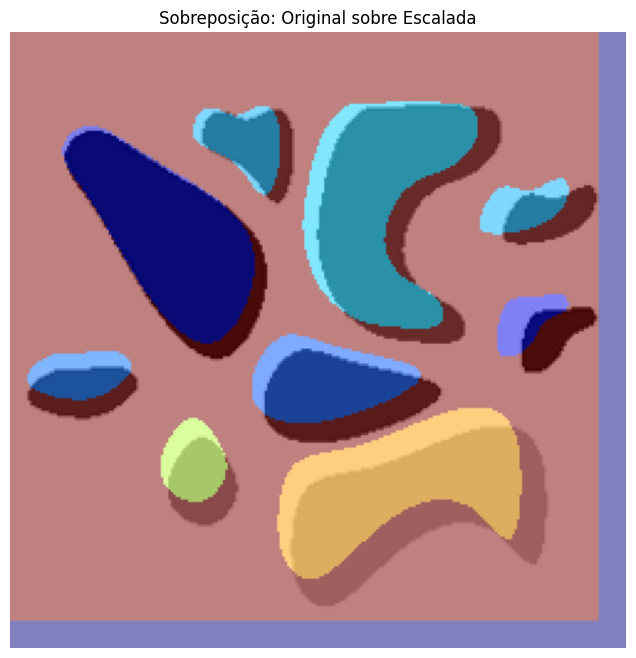

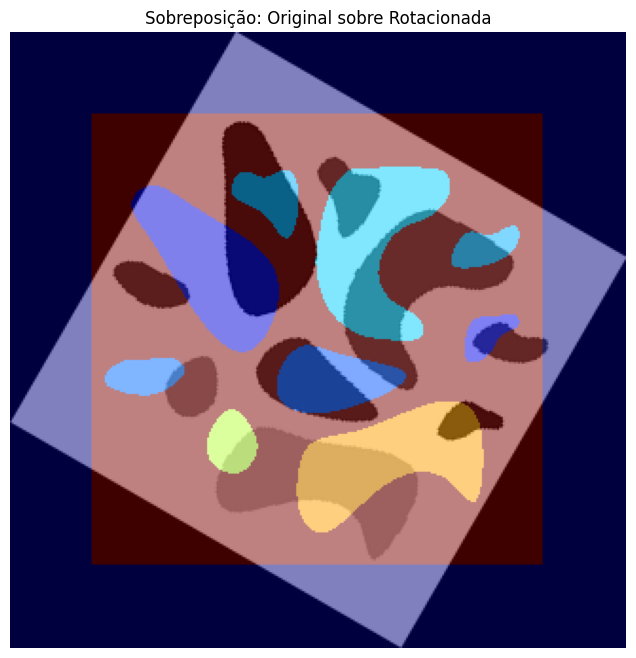

In [80]:
# Sobreposição: Original sobre Escalada
h_esc, w_esc = imagem_esc.shape
h_ori, w_ori = imagem.shape

canvas_esc = np.zeros_like(imagem_esc)
canvas_esc[:h_ori, :w_ori] = imagem

plt.figure(figsize=(8, 8))
plt.imshow(imagem_esc, cmap='gray', alpha=1.0)  # fundo: imagem escalada
plt.imshow(canvas_esc, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Escalada")
plt.axis('off')
plt.show()

# Sobreposição: Original sobre Rotacionada
h_rot, w_rot = imagem_rot.shape

canvas_rot = np.zeros_like(imagem_rot)

offset_y = (h_rot - h_ori) // 2
offset_x = (w_rot - w_ori) // 2

if offset_y >= 0 and offset_x >= 0:
    canvas_rot[offset_y:offset_y+h_ori, offset_x:offset_x+w_ori] = imagem
else:
    canvas_rot[:min(h_rot, h_ori), :min(w_rot, w_ori)] = imagem[:min(h_rot, h_ori), :min(w_rot, w_ori)]

plt.figure(figsize=(8, 8))
plt.imshow(imagem_rot, cmap='gray', alpha=1.0)  # fundo: imagem rotacionada
plt.imshow(canvas_rot, cmap='jet', alpha=0.5)   # sobreposição: imagem original colorida e transparente
plt.title("Sobreposição: Original sobre Rotacionada")
plt.axis('off')
plt.show()
